In [67]:
#importing important libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [68]:
# Load Data

df = pd.read_excel("Assessment Responses.xlsx")

In [4]:
#Performing EDA

In [69]:
# 1. Basic Structure

print(df.shape)
print(df.info())

# -------------------------
# 2. Missing Values
# -------------------------
print(df.isnull().sum())

df.columns = df.columns.str.strip()

# -------------------------
# 3. Duplicate Rows
# -------------------------
print("Duplicates:", df.duplicated().sum())

# -------------------------
# 4. AI Usage Count
# -------------------------
print(df["Do you use Generative AI for your office work?"].value_counts())

# -------------------------
# 5. Frequency of AI Usage
# -------------------------
users = df[df["Do you use Generative AI for your office work?"]=="Yes"]

print(users["Frequency of AI usage at work?"].value_counts())

# -------------------------
# 6. Time Saved
# -------------------------
print(users["Estimated % time saved due to AI."].value_counts())

# -------------------------
# 7. Before vs After Task Time
# -------------------------
print(users["Average time to complete a standard task BEFORE AI."].value_counts())
print(users["Average time to complete the same task AFTER AI."].value_counts())


(50, 26)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 26 columns):
 #   Column                                                                               Non-Null Count  Dtype 
---  ------                                                                               --------------  ----- 
 0   Name                                                                                 50 non-null     object
 1   Gender                                                                               50 non-null     object
 2   Organization Name                                                                    50 non-null     object
 3   Current Role                                                                         50 non-null     object
 4   Years of experience                                                                  50 non-null     object
 5   Industry or Domain                                                                   50 non-

In [44]:
# Rename columns
df = df.rename(columns={
    "Name": "name",
    "Gender": "gender",
    "Organization Name": "organization",
    "Current Role": "role",
    "Years of experience": "experience",
    "Industry or Domain": "industry",

    "Do you use Generative AI for your office work?": "ai_usage",
    "Which AI tools do you use?": "ai_tools",
    "How long have you been using Generative AI at work?": "ai_duration",
    "Frequency of AI usage at work?": "ai_frequency",
    "What are the Primary tasks for which you use Generative AI?": "ai_tasks",
    "Approximately what percentage of your tasks involve AI assistance?": "ai_task_percent",

    "Average time to complete a standard task BEFORE AI.": "time_before",
    "Average time to complete the same task AFTER AI.": "time_after",
    "Estimated % time saved due to AI.": "time_saved",

    "AI enablement helps to complete a higher volume of tasks within the same time frame": "prod_volume",
    "AI reduces your manual effort and repetitive work in my daily tasks.": "prod_effort",
    "AI helps you to identify errors and resolve faster to reduces rework.": "reduce_rework",
    "AI improves the quality and accuracy of my deliverables.": "quality_accuracy",

    "What is the primary reason for not using Generative AI tools ?": "no_ai_reason",
    "Do you believe Generative AI could improve your productivity?": "ai_belief",

    "Faster_Project_Delivery": "Faster_delivery",
    "reduce_project_duration_cost": "cost_reduction",
    "Improve_efficiency_and_resource_utilisation": "team_efficiency",
    "strengthens_organization’s_competitive_advantage": "competitive_advantage",
    "supportive_tool_rather_risk_for_work": "ai_support"
})

# Show updated columns
print(df.columns)


Index(['name', 'gender', 'organization', 'role', 'experience', 'industry',
       'ai_usage', 'ai_tools', 'ai_duration', 'ai_frequency', 'ai_tasks',
       'ai_task_percent', 'time_before', 'time_after', 'time_saved',
       'prod_volume', 'prod_effort', 'reduce_rework', 'quality_accuracy',
       'no_ai_reason', 'ai_belief', 'Faster_delivery', 'cost_reduction',
       'team_efficiency', 'competitive_advantage', 'ai_support'],
      dtype='object')


In [45]:
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)


In [46]:
# ---------------------------------------
# Fill blanks first
# ---------------------------------------
df = df.replace(r'^\s*$', "0", regex=True)
df = df.fillna("0")

# ---------------------------------------
# Numeric Mappings
# ---------------------------------------
#Since survey responses were collected in ranges, midpoints were used as representative values for quantitative analysis. 
#This is a standard approximation technique in survey-based research.

# took the midpoint of each range, average experience in that range
exp_map = {
    "0-2": 1,
    "3-5": 4,
    "6-10": 8,
    "10 and more": 12,
    "0": 0
}
#midpoint logic- approximate months
duration_map = {
    "1-3 months": 2,
    "4-6 months": 5,
    "7-12 months": 9.5,
    "More than a year": 15,
    "0": 0

}


#relative scale values - it's a ranking scale
freq_map = {
    "Daily": 5,
    "3-4 times/week": 3,
    "Weekly": 1,
    "Occasionally": 2,   # fixed spelling
    "0": 0
}
#midpoint of percentage ranges 
time_map = {
    "Less than 2 hours": 1,
    "2-4 hours": 3,
    "4-6 hours": 5,
    "6-8 hours": 7,
    "More than 8 hours": 9,
    "0": 0
}

saved_map = {
    "0-10%": 5,
    "10-25%": 17.5,
    "25-50%": 37.5,
    "More than 50%": 60,   # fixed space issue
    "More than 50 %": 60,  # keeping safety for messy data
    "0": 0
}

#Categorical variables were retained for segmentation,
#while numerical transformations were applied to enable statistical analysis such as regression and hypothesis testing.

likert_map = {
    "Strongly Agree": 5,
    "Strongly agree": 5,
    "Agree": 4,
    "Neutral": 3,
    "Disagree": 2,
    "Strongly Disagree": 1,
    "0": 0
}

likert_map = {
    "Strongly Disagree": 1,
    "Disagree": 2,
    "Neutral": 3,
    "Agree": 4,
    "Strongly agree": 5,
    "Strongly Agree": 5
}
task_map = {
    "0-10%": 5,
    "0-10 %": 5,
    "10-25%": 17.5,
    "25-50%": 37.5,
    "More than 50%": 60,
    "More than 50 %": 60,
    "0": 0
}

# ---------------------------------------
# Apply Numeric Conversion
# ---------------------------------------

df["experience_num"] = df["experience"].astype(str).map(exp_map)

df["ai_duration_num"] = df["ai_duration"].astype(str).map(duration_map)

df["ai_frequency_num"] = df["ai_frequency"].astype(str).map(freq_map)

df["time_before_num"] = df["time_before"].astype(str).map(time_map)

df["time_after_num"] = df["time_after"].astype(str).map(time_map)

df["time_saved_num"] = df["time_saved"].astype(str).map(saved_map)

df["ai_task_percent"] = df["ai_task_percent"].str.strip()
# ---------------------------------------
# Likert Columns Mapping (FIXED NAMES)
# ---------------------------------------

likert_cols = [
    "prod_volume",
    "prod_effort",
    "reduce_rework",
    "quality_accuracy",
    "Faster_delivery",
    "cost_reduction",
    "team_efficiency",
    "competitive_advantage"
]

for col in likert_cols:
    df[col + "_num"] = df[col].astype(str).map(likert_map)

# ---------------------------------------
# Final cleanup
# ---------------------------------------
df = df.fillna(0)

# ---------------------------------------
# Check output
# ---------------------------------------

# Save file
df.to_excel("final_cleaned_numeric.xlsx", index=False)

       name  gender             organization  \
0  Navedita  Female                       Ey   
1    Akshit    Male                      TCS   
2    Krithi  Female  Worldpanel by Numerator   
3   Gunjesh    Male                      JSL   
4  Chanchal  Female                      TCS   

                               role   experience       industry ai_usage  \
0                        Consultant          0-2     Consulting      Yes   
1                  Business Analyst          3-5    IT Services      Yes   
2     Data Engineer or Data Analyst          3-5    IT Services      Yes   
3  Project Manager or Product Owner  10 and more  Manufacturing      Yes   
4                  Business Analyst         6-10    IT Services      Yes   

                                     ai_tools  ai_duration    ai_frequency  \
0          ChatGPT, Microsoft Copilot, Gemini   4-6 months           Daily   
1                  ChatGPT, Microsoft Copilot  7-12 months           Daily   
2  ChatGPT, GitHub C

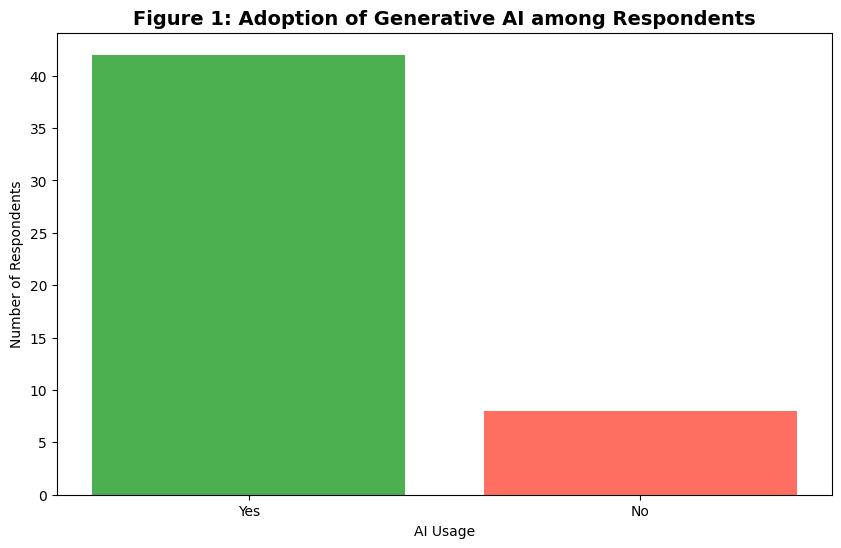

In [9]:
import matplotlib.pyplot as plt

ai_counts = df["ai_usage"].value_counts()

plt.figure(figsize=(10,6))
colors = ["#4CAF50", "#FF6F61"]

plt.bar(ai_counts.index, ai_counts.values, color=colors)

plt.title("Figure 1: Adoption of Generative AI among Respondents", fontsize=14, fontweight="bold")
plt.xlabel("AI Usage")
plt.ylabel("Number of Respondents")

plt.savefig("figure1_ai_adoption.png", dpi=300, bbox_inches='tight')
plt.show()

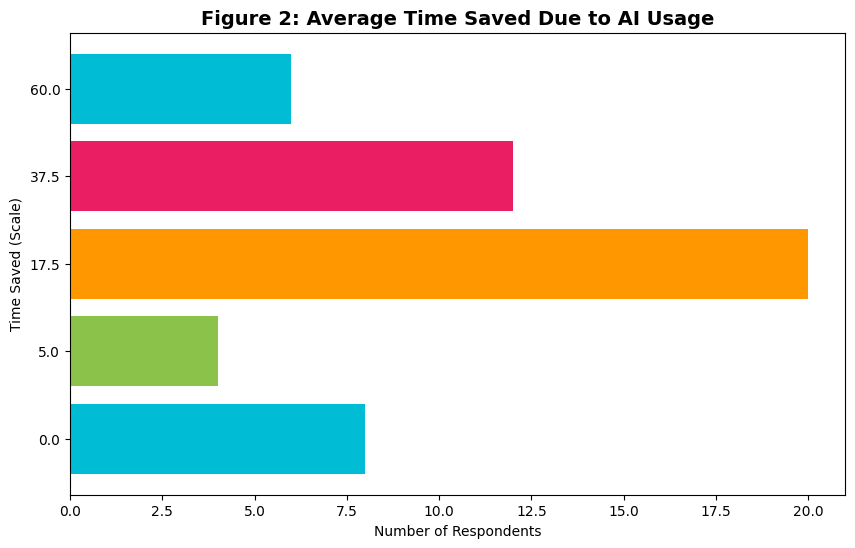

In [10]:
time_counts = df["time_saved_num"].value_counts().sort_index()

plt.figure(figsize=(10,6))
colors = ["#00BCD4", "#8BC34A", "#FF9800", "#E91E63"]

plt.barh(time_counts.index.astype(str), time_counts.values, color=colors)

plt.title("Figure 2: Average Time Saved Due to AI Usage", fontsize=14, fontweight="bold")
plt.xlabel("Number of Respondents")
plt.ylabel("Time Saved (Scale)")

plt.savefig("figure2_time_saved.png", dpi=300, bbox_inches='tight')
plt.show()

<Figure size 1200x700 with 0 Axes>

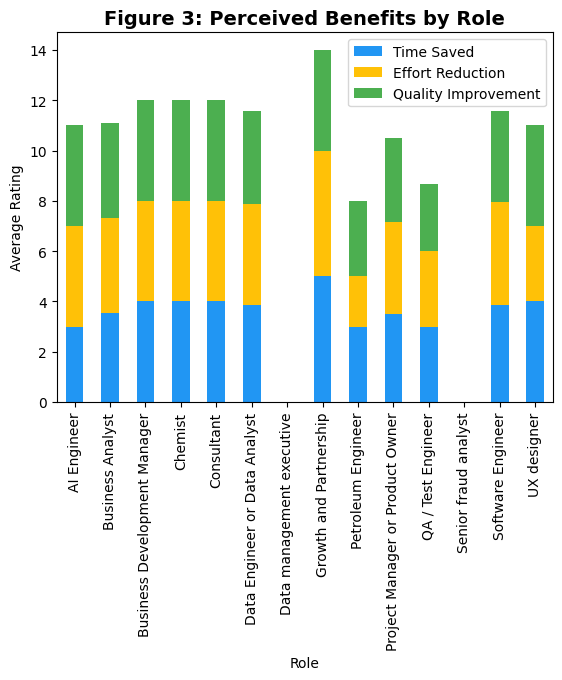

In [47]:
# Aggregate directly (no renaming needed)
benefits = df.groupby("role")[[
    "prod_volume_num",
    "prod_effort_num",
    "quality_accuracy_num"
]].mean()

plt.figure(figsize=(12,7))

benefits.plot(
    kind="bar",
    stacked=True,
    color=["#2196F3", "#FFC107", "#4CAF50"]
)

plt.title("Figure 3: Perceived Benefits by Role", fontsize=14, fontweight="bold")
plt.xlabel("Role")
plt.ylabel("Average Rating")

plt.legend(["Time Saved", "Effort Reduction", "Quality Improvement"])

plt.savefig("figure3_perceived_benefits.png", dpi=300, bbox_inches='tight')
plt.show()

In [48]:
task_map = {
    "0-10%": 5,
    "0-10 %": 5,
    "10-25%": 17.5,
    "25-50%": 37.5,
    "More than 50%": 60,
    "More than 50 %": 60,
    "0": 0
}
df["ai_task_percent"] = df["ai_task_percent"].str.strip()
df["ai_task_percent_num"] = df["ai_task_percent"].map(task_map)
print(df[["ai_task_percent", "ai_task_percent_num"]].head())

  ai_task_percent  ai_task_percent_num
0          25-50%                 37.5
1          25-50%                 37.5
2          25-50%                 37.5
3          0-10 %                  5.0
4          10-25%                 17.5


In [49]:
print(df[[
    'ai_frequency_num',
    'ai_task_percent_num',
    'time_before_num',
    'time_after_num',
    'time_saved_num',
    'prod_volume_num',
    'prod_effort_num',
    'reduce_rework_num',
    'quality_accuracy_num'
]].head())

   ai_frequency_num  ai_task_percent_num  time_before_num  time_after_num  \
0                 5                 37.5                5               3   
1                 5                 37.5                3               1   
2                 5                 37.5                5               1   
3                 5                  5.0                3               1   
4                 3                 17.5                5               3   

   time_saved_num  prod_volume_num  prod_effort_num  reduce_rework_num  \
0            37.5              4.0              4.0                4.0   
1            17.5              5.0              4.0                4.0   
2            37.5              4.0              5.0                5.0   
3            17.5              5.0              5.0                4.0   
4            17.5              3.0              4.0                4.0   

   quality_accuracy_num  
0                   4.0  
1                   4.0  
2             

In [66]:

# ----------  Productivity Calculator ----------
def productivity_calculator(row):

    # Core inputs
    freq_score = row['ai_frequency_num']
    tasks_assisted_pct = row['ai_task_percent_num']  
    time_before = row['time_before_num']
    time_after = row['time_after_num']

    # Perceived benefits (Likert 1–5 → scaled to 0–100)
    perceived_benefits = row[
        ['prod_volume_num',
         'prod_effort_num',
         'reduce_rework_num',
         'quality_accuracy_num']
    ].mean() * 20

    # Core calculations
    time_saved = time_before - time_after

    productivity_gain = (
        (time_saved / time_before) * 100
        if pd.notna(time_before) and time_before > 0 else 0
    )

    # AI Productivity Index
    api = (
        0.3 * freq_score +
        0.2 * tasks_assisted_pct +
        0.3 * productivity_gain +
        0.2 * perceived_benefits
    )

    return pd.Series({
        'time_saved_per_task': time_saved,
        'productivity_gain_pct': productivity_gain,
        'ai_productivity_index': api
    })


# ---------- Step 3: Apply ----------
results = df.apply(productivity_calculator, axis=1)

# ---------- Step 4: Merge ----------
df_final = pd.concat([df, results], axis=1)


In [15]:
from scipy import stats

# Paired t-test
t_stat, p_val = stats.ttest_rel(df['time_before_num'], df['time_after_num'])
print("Paired t-test:", t_stat, p_val)


Paired t-test: 7.978404478640455 2.0614603635818432e-10


In [16]:
#Independent t-test (AI Users vs. Non-users)
from scipy import stats

# Split groups
users = df_final[df_final['ai_usage'] == 'Yes']['productivity_gain_pct']
non_users = df_final[df_final['ai_usage'] == 'No']['productivity_gain_pct']

# Remove missing values (VERY IMPORTANT)
users = users.dropna()
non_users = non_users.dropna()

# Welch’s t-test (no equal variance assumption)
t_stat, p_val = stats.ttest_ind(users, non_users, equal_var=False)

print("T-statistic:", t_stat)
print("Two-tailed p-value:", p_val)

# One-tailed p-value (since your hypothesis is positive impact)
if t_stat > 0:
    p_val_one_tailed = p_val / 2
else:
    p_val_one_tailed = 1 - (p_val / 2)

print("One-tailed p-value:", p_val_one_tailed)

T-statistic: 14.567221664387448
Two-tailed p-value: 8.322467581169881e-18
One-tailed p-value: 4.161233790584941e-18


In [51]:
#Regression Analysis

#T-test = comparison, Regression = impact
#We used regression to understand how the level of AI usage (frequency and duration) impacts employee productivity

import statsmodels.api as sm

X = df_final[['ai_frequency_num', 'ai_task_percent_num']]
y = df_final['productivity_gain_pct']

# Remove missing values (VERY IMPORTANT)
data = pd.concat([X, y], axis=1).dropna()

X = data[['ai_frequency_num', 'ai_task_percent_num']]
y = data['productivity_gain_pct']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                              OLS Regression Results                             
Dep. Variable:     productivity_gain_pct   R-squared:                       0.604
Model:                               OLS   Adj. R-squared:                  0.587
Method:                    Least Squares   F-statistic:                     35.83
Date:                   Thu, 28 May 2026   Prob (F-statistic):           3.54e-10
Time:                           19:05:47   Log-Likelihood:                -219.79
No. Observations:                     50   AIC:                             445.6
Df Residuals:                         47   BIC:                             451.3
Df Model:                              2                                         
Covariance Type:               nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
cons

In [18]:
#ANOVA Analysis of Role 
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Use df_final (important)
anova_model = smf.ols('ai_productivity_index ~ C(role)', data=df_final).fit()

anova_table = sm.stats.anova_lm(anova_model, typ=2)

print(anova_table)

                sum_sq    df         F    PR(>F)
C(role)    3607.139854  13.0  0.818176  0.638533
Residual  12208.866280  36.0       NaN       NaN


In [52]:
# Remove missing values before ANOVA
df_anova = df_final[['ai_productivity_index', 'role']].dropna()

anova_model = smf.ols('ai_productivity_index ~ C(role)', data=df_anova).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)

print(anova_table)

                sum_sq    df         F    PR(>F)
C(role)    3607.139854  13.0  0.818176  0.638533
Residual  12208.866280  36.0       NaN       NaN


In [53]:
#ANOVA Analysis of Industry Differences  
import statsmodels.api as sm
import statsmodels.formula.api as smf

# ANOVA by industry/domain
anova_model_industry = smf.ols('ai_productivity_index ~ C(industry)', data=df_final).fit()

anova_table_industry = sm.stats.anova_lm(anova_model_industry, typ=2)

print(anova_table_industry)


                   sum_sq    df         F   PR(>F)
C(industry)   3540.223650  10.0  1.124724  0.36925
Residual     12275.782484  39.0       NaN      NaN


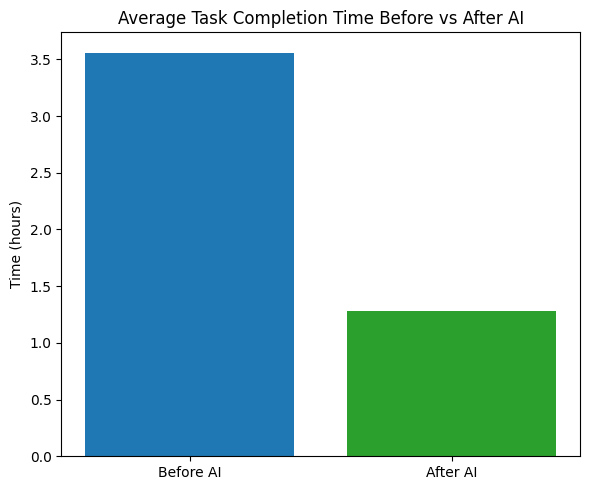

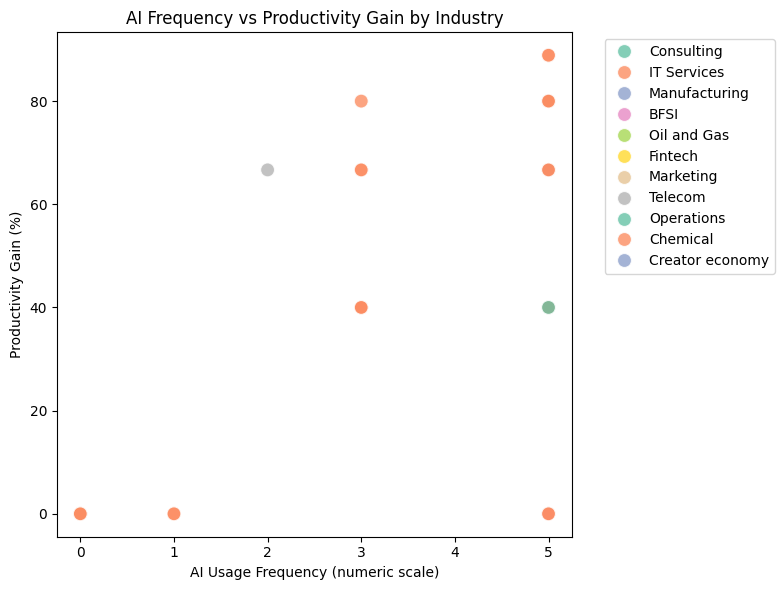

C:\Users\Dell\AppData\Local\Temp\ipykernel_14892\2973315945.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


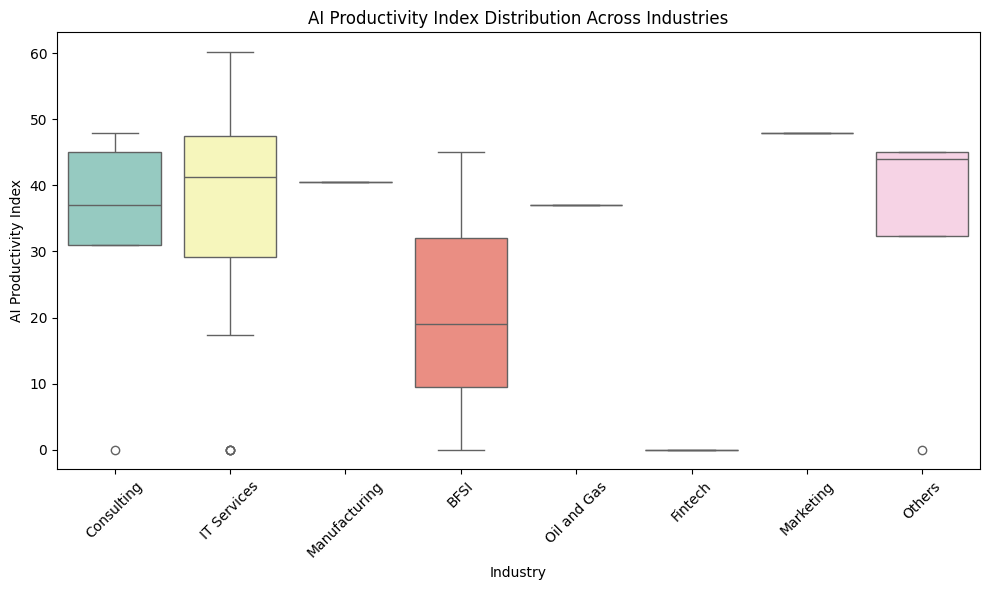

In [54]:
#Paired Bar Chart — Task Times Before vs. After AI
import matplotlib.pyplot as plt
import numpy as np

# Average task times
avg_before = df_final['time_before_num'].mean()
avg_after = df_final['time_after_num'].mean()

# Bar chart
labels = ['Before AI', 'After AI']
values = [avg_before, avg_after]

plt.figure(figsize=(6,5))
plt.bar(labels, values, color=['#1f77b4', '#2ca02c'])  # blue & green
plt.title('Average Task Completion Time Before vs After AI')
plt.ylabel('Time (hours)')
plt.tight_layout()
plt.savefig("paired_bar_chart.png", dpi=300)  # save as PNG
plt.show()


#Scatter Plot — AI Frequency vs. Productivity Gain
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.scatterplot(
    x='ai_frequency_num',
    y='productivity_gain_pct',
    data=df_final,
    hue='industry',
    palette='Set2',   # attractive pastel palette
    s=100,            # larger points
    alpha=0.8         # slight transparency
)

plt.title('AI Frequency vs Productivity Gain by Industry')
plt.xlabel('AI Usage Frequency (numeric scale)')
plt.ylabel('Productivity Gain (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("scatter_plot.png", dpi=300)  # save as PNG
plt.show()


#Boxplot — API Distribution Across Industries
# Define top 7 industries
top_industries = df_final['industry'].value_counts().nlargest(7).index

# Replace non-top industries with 'Others'
df_final['industry_grouped'] = df_final['industry'].apply(
    lambda x: x if x in top_industries else 'Others'
)

plt.figure(figsize=(10,6))
sns.boxplot(
    x='industry_grouped',
    y='ai_productivity_index',
    data=df_final,
    palette='Set3'   # attractive categorical palette
)

plt.title('AI Productivity Index Distribution Across Industries')
plt.xlabel('Industry')
plt.ylabel('AI Productivity Index')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("boxplot_industries.png", dpi=300)  # save as PNG
plt.show()



In [22]:
#Project-Level Analysis

import statsmodels.api as sm

# Predictors (individual productivity drivers)
X = df[[
    'time_saved_num',
    'ai_frequency_num',
    'ai_task_percent_num'
]]

X = sm.add_constant(X)

# Project-level outcomes
project_outcomes = [
    'Faster_delivery_num',
    'cost_reduction_num',
    'team_efficiency_num',
    'competitive_advantage_num'
]

# Run regression for each outcome
for outcome in project_outcomes:
    print(f"\n--- Regression for {outcome} ---")
    
    y = df[outcome]
    
    model = sm.OLS(y, X).fit()
    print(model.summary())


--- Regression for Faster_delivery_num ---
                             OLS Regression Results                            
Dep. Variable:     Faster_delivery_num   R-squared:                       0.128
Model:                             OLS   Adj. R-squared:                  0.071
Method:                  Least Squares   F-statistic:                     2.256
Date:                 Thu, 28 May 2026   Prob (F-statistic):             0.0945
Time:                         19:03:35   Log-Likelihood:                -39.030
No. Observations:                   50   AIC:                             86.06
Df Residuals:                       46   BIC:                             93.71
Df Model:                            3                                         
Covariance Type:             nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

In [23]:
!pip install factor-analyzer


In [24]:
!python -m pip install --upgrade pip

In [55]:
from factor_analyzer import FactorAnalyzer

In [56]:
#Factor Analysis
from factor_analyzer import FactorAnalyzer

# Select correct project-level numeric variables
project_vars = df[[
    'Faster_delivery_num',
    'cost_reduction_num',
    'team_efficiency_num',
    'competitive_advantage_num'
]]

# Run factor analysis
fa = FactorAnalyzer(n_factors=1, rotation='varimax')
fa.fit(project_vars)

# Factor loadings
loadings = fa.loadings_
print("Factor Loadings:\n", loadings)

# Variance explained
variance = fa.get_factor_variance()
print("Variance Explained:\n", variance)


Factor Loadings:
 [[-0.72113119]
 [-0.85289081]
 [-0.92941329]
 [-0.78610744]]
Variance Explained:
 (array([2.7292269]), array([0.68230673]), array([0.68230673]))


C:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\factor_analyzer\factor_analyzer.py:663: UserWarning: No rotation will be performed when the number of factors equals 1.
  warnings.warn(


In [57]:
# Convert numeric project outcomes into categories

df['faster_delivery_cat'] = pd.cut(df['Faster_delivery_num'],
                                   bins=[0, 2, 3, 5],
                                   labels=['Low', 'Medium', 'High'])

df['reduced_cost_cat'] = pd.cut(df['cost_reduction_num'],
                                 bins=[0, 2, 3, 5],
                                 labels=['Low', 'Medium', 'High'])

df['efficiency_cat'] = pd.cut(df['team_efficiency_num'],
                              bins=[0, 2, 3, 5],
                              labels=['Low', 'Medium', 'High'])

df['competitive_advantage_cat'] = pd.cut(df['competitive_advantage_num'],
                                        bins=[0, 2, 3, 5],
                                        labels=['Low', 'Medium', 'High'])

#Chi-Square Tests
import pandas as pd
from scipy.stats import chi2_contingency

project_outcomes_cat = [
    'faster_delivery_cat',
    'reduced_cost_cat',
    'efficiency_cat',
    'competitive_advantage_cat'
]

for outcome in project_outcomes_cat:
    print(f"\n--- Chi-Square Test: AI Usage vs {outcome} ---")
    
    contingency_table = pd.crosstab(df['ai_usage'], df[outcome])
    print("Contingency Table:\n", contingency_table)
    
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    
    print("Chi-square statistic:", chi2)
    print("p-value:", p)
    print("Degrees of freedom:", dof)



--- Chi-Square Test: AI Usage vs faster_delivery_cat ---
Contingency Table:
 faster_delivery_cat  Medium  High
ai_usage                         
No                        1     7
Yes                       3    39
Chi-square statistic: 0.0
p-value: 1.0
Degrees of freedom: 1

--- Chi-Square Test: AI Usage vs reduced_cost_cat ---
Contingency Table:
 reduced_cost_cat  Medium  High
ai_usage                      
No                     4     4
Yes                    5    36
Chi-square statistic: 4.108335450542006
p-value: 0.04267234176879738
Degrees of freedom: 1

--- Chi-Square Test: AI Usage vs efficiency_cat ---
Contingency Table:
 efficiency_cat  Low  Medium  High
ai_usage                         
No                0       2     6
Yes               1       4    37
Chi-square statistic: 1.665743816906608
p-value: 0.4347987892062033
Degrees of freedom: 2

--- Chi-Square Test: AI Usage vs competitive_advantage_cat ---
Contingency Table:
 competitive_advantage_cat  Low  Medium  High
ai_usag

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# Example regression coefficients (replace with your actual values)
coeffs = {
    'Faster Delivery': {'time_saved_num': 0.017, 'ai_frequency_num': -0.025, 'ai_task_percent_num': -0.010},
    'Cost Reduction': {'time_saved_num': 0.021, 'ai_frequency_num': -0.024, 'ai_task_percent_num': -0.014},
    'Team Efficiency': {'time_saved_num': 0.014, 'ai_frequency_num': -0.018, 'ai_task_percent_num': -0.007},
    'Competitive Advantage': {'time_saved_num': 0.014, 'ai_frequency_num': -0.058, 'ai_task_percent_num': -0.006}
}

df_coeffs = pd.DataFrame(coeffs).T

# Plot
ax = df_coeffs.plot(kind='bar', figsize=(10,6))
plt.title("Regression Coefficients Across Project-Level Outcomes")
plt.ylabel("Coefficient Value")
plt.xlabel("Project-Level Outcomes")
plt.legend(title="Predictors")
plt.tight_layout()

# Save as PNG
plt.savefig("Figure_4_4_1_Regression_Coefficients.png", dpi=300)
plt.close()


In [29]:
import matplotlib.pyplot as plt

# Example factor loadings (replace with your actual loadings)
loadings = {
    'Faster Delivery': -0.72,
    'Cost Reduction': -0.85,
    'Team Efficiency': -0.93,
    'Competitive Advantage': -0.79
}

plt.figure(figsize=(8,6))
plt.bar(loadings.keys(), loadings.values(), color='skyblue')
plt.title("Factor Loadings on AI-Driven Project Efficiency")
plt.ylabel("Loading Value")
plt.xlabel("Project-Level Outcomes")
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()

# Save as PNG
plt.savefig("Figure_4_4_2_Factor_Loadings.png", dpi=300)
plt.close()


In [58]:
import pandas as pd
import matplotlib.pyplot as plt

# Example contingency data (replace with your actual counts)
data = {
    'Outcome': ['Faster Delivery', 'Cost Reduction', 'Team Efficiency', 'Competitive Advantage'],
    'AI Usage - High': [39, 36, 37, 39],
    'AI Usage - Medium/Low': [3, 5, 5, 3],
    'Non-AI Usage - High': [7, 4, 6, 7],
    'Non-AI Usage - Medium/Low': [1, 4, 2, 1]
}

df_ct = pd.DataFrame(data)

# Plot stacked bars
ax = df_ct.set_index('Outcome')[[
    'AI Usage - High','AI Usage - Medium/Low',
    'Non-AI Usage - High','Non-AI Usage - Medium/Low'
]].plot(kind='bar', stacked=True, figsize=(10,6), colormap='tab20')

plt.title("AI Usage vs Project-Level Outcomes (Categorical)")
plt.ylabel("Number of Respondents")
plt.xlabel("Project-Level Outcomes")
plt.legend(title="Response Category")
plt.tight_layout()

# Save as PNG
plt.savefig("Figure_4_4_3_ChiSquare_Contingency.png", dpi=300)
plt.close()


In [59]:
import pandas as pd
# Distribution of supportive vs risk perceptions
perception_counts = df['ai_support'].value_counts(normalize=True) * 100
print("Perception Distribution (%):\n", perception_counts)



Perception Distribution (%):
 ai_support
Agree             56.0
Strongly Agree    26.0
Netural           18.0
Name: proportion, dtype: float64


In [60]:
from scipy.stats import chi2_contingency
import pandas as pd

# Build contingency table
contingency_table = pd.crosstab(df['ai_usage'], df['ai_support'])
print("Contingency Table:\n", contingency_table)

# Run chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)
print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)
print("Expected frequencies:\n", expected)


Contingency Table:
 ai_support  Agree  Netural  Strongly Agree
ai_usage                                  
No              4        2               2
Yes            24        7              11
Chi-square statistic: 0.3241467527181814
p-value: 0.8503788045503932
Degrees of freedom: 2
Expected frequencies:
 [[ 4.48  1.44  2.08]
 [23.52  7.56 10.92]]


In [61]:
import statsmodels.api as sm

# Map categories to binary
df['perception_binary'] = df['ai_support'].map({
    'Agree': 1,
    'Strongly Agree': 1,
    'Netural': 0   # fix spelling if needed
})

# Drop missing values
df = df.dropna(subset=['perception_binary'])

# Predictors
X = df[['time_saved_num', 'ai_frequency_num', 'ai_task_percent_num']]
X = sm.add_constant(X)
y = df['perception_binary'].astype(int)

# Logistic regression
logit_model = sm.Logit(y, X).fit()
print(logit_model.summary())


Optimization terminated successfully.
         Current function value: 0.460634
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:      perception_binary   No. Observations:                   50
Model:                          Logit   Df Residuals:                       46
Method:                           MLE   Df Model:                            3
Date:                Thu, 28 May 2026   Pseudo R-squ.:                 0.02282
Time:                        19:06:21   Log-Likelihood:                -23.032
converged:                       True   LL-Null:                       -23.570
Covariance Type:            nonrobust   LLR p-value:                    0.7829
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   1.0401      0.719      1.446      0.148      -0.370       2.450
ti

In [65]:
print(df['ai_support'].unique())


['Agree' 'Strongly Agree' 'Netural']
